In [5]:
!pip install xgboost

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from xgboost import XGBRegressor

In [7]:
df = pd.read_csv(
    r"C:\Users\nikhi\Downloads\archive\Sample - Superstore.csv",
    encoding="latin1"
)
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [9]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df = df.sort_values("Order Date")

In [10]:
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Day"] = df["Order Date"].dt.day
df["Weekday"] = df["Order Date"].dt.dayofweek
df["DayOfYear"] = df["Order Date"].dt.dayofyear 
df["Is_Weekend"] = df["Weekday"].isin([5,6]).astype(int)

In [11]:
df["Lag_1"] = df["Sales"].shift(1) 
df["Lag_7"] = df["Sales"].shift(7) 
df["Rolling_Mean_7"] = df["Sales"].rolling(7).mean() 
df["Rolling_Mean_30"] = df["Sales"].rolling(30).mean() 
df["Rolling_Max_7"] = df["Sales"].rolling(7).max() 

In [12]:
df = df.dropna()
print("Rows after dropping NaN:", df.shape[0])

Rows after dropping NaN: 9965


In [13]:
df = pd.get_dummies(
    df,
    columns=["Category", "Ship Mode", "Segment", "Region"], # added Ship Mode
    drop_first=True
)

In [14]:
X = df.select_dtypes(include=["int64","float64"])
X = X.drop("Sales", axis=1)

y = df["Sales"]
y_log = np.log1p(y) 

In [15]:
X_train, X_test, y_train_log, y_test_log = train_test_split(
    X, y_log, test_size=0.2, shuffle=False # shuffle=False = no cheating
)

In [16]:
model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.03, 
    max_depth=8,
    subsample=0.8, 
    colsample_bytree=0.8, 
    min_child_weight=5,
    reg_alpha=0.1,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train_log)
print("Model trained successfully")

Model trained successfully


In [17]:
pred_log = model.predict(X_test)
pred = np.expm1(pred_log) 
y_test = np.expm1(y_test_log) 
print("First 5 predictions:", pred[:5])

First 5 predictions: [326.5099   542.5566    24.416172 260.83243  129.41638 ]


In [18]:
mae = mean_absolute_error(y_test, pred)
r2 = r2_score(y_test, pred)

print("MAE:", round(mae, 2))
print("R2:", round(r2, 3))
print("Baseline MAE if predicting mean:", round(mean_absolute_error(y_test, [y_test.mean()]*len(y_test)), 2))

MAE: 78.75
R2: 0.814
Baseline MAE if predicting mean: 264.06


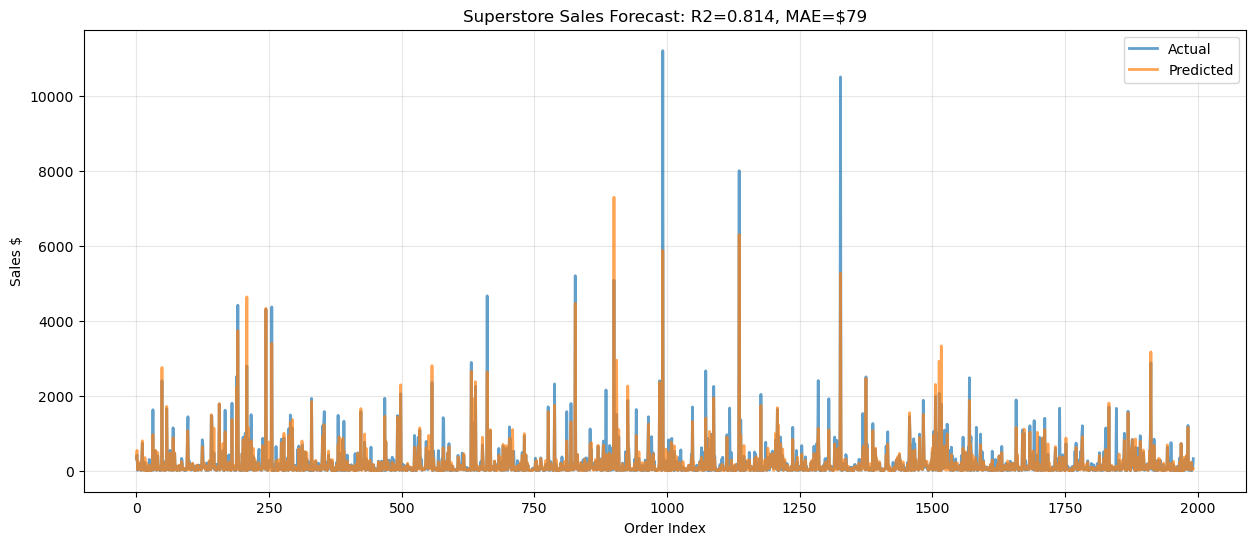

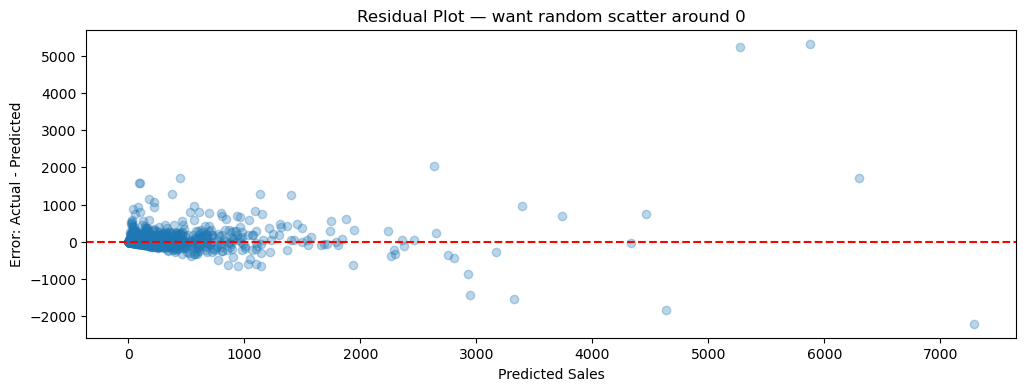

In [19]:
plt.figure(figsize=(15,6))
plt.plot(y_test.values, label="Actual", alpha=0.7, linewidth=2)
plt.plot(pred, label="Predicted", alpha=0.7, linewidth=2)
plt.title(f'Superstore Sales Forecast: R2={r2:.3f}, MAE=${mae:.0f}')
plt.ylabel('Sales $')
plt.xlabel('Order Index')
plt.legend()
plt.grid(alpha=0.3)
plt.show()
errors = y_test - pred
plt.figure(figsize=(12,4))
plt.scatter(pred, errors, alpha=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Sales')
plt.ylabel('Error: Actual - Predicted')
plt.title('Residual Plot — want random scatter around 0')
plt.show()

In [20]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)
print(importance.head(10))
result = pd.DataFrame({
    "Order_Date": df["Order Date"].iloc[-len(y_test):].values,
    "Actual": y_test.values,
    "Predicted": pred
})
result.to_csv("superstore_forecast.csv", index=False)
print("superstore_forecast.csv created")

            Feature  Importance
4            Profit    0.453711
3          Discount    0.243307
2          Quantity    0.103343
8    Rolling_Mean_7    0.046121
10    Rolling_Max_7    0.032178
1       Postal Code    0.024814
6             Lag_1    0.021505
0            Row ID    0.020104
7             Lag_7    0.019589
9   Rolling_Mean_30    0.019507
superstore_forecast.csv created
